# Classificação de Gêneros Musicais — do K-Means ao 1º lugar (LB 0,83024)

**Competição:** *ISMIS 2011 Contest — Music Information Retrieval* (Kaggle) · **Tarefa:** classificar segmentos de música em **6 gêneros** (Blues, Classical, Jazz, Metal, Pop, Rock) a partir de **191 features de áudio** pré-extraídas.

**Resultado final:** **0,83024** de acurácia no leaderboard com a submissão `submissao_v14.csv` — **1º lugar** (meta original de 0,80 batida na v6; meta estendida de 0,83 batida na v14).

Este notebook consolida **toda a trajetória do projeto** em um único documento, para servir de base ao artigo: o que foi tentado, o que funcionou, o que falhou e por quê. A jornada tem um fio condutor claro:

> A validação local dizia **97,6%**; o leaderboard devolveu **72,8%**. Todo o restante do projeto foi diagnosticar esse abismo (*covariate shift*) e construir, passo a passo, uma solução robusta a ele — até chegar a **83,0%**.

**Sumário**
1. O problema e os dados
2. Linha do tempo: todas as versões e seus resultados
3. Etapa 1 — abordagem não supervisionada (K-Means)
4. Etapa 2 — modelos supervisionados (7 algoritmos)
5. O choque do leaderboard e a validação adversarial
6. Etapa 3 — atacando o shift: features DCT + pseudo-rotulagem (v3)
7. v4 — correção de *label shift* (EM de Saerens)
8. v5 — EM dentro do laço + alinhamento de distribuição (estilo FixMatch)
9. v6 — *bagging* do processo completo · v9 — consenso de música (recorde)
10. O que foi testado e **não** funcionou
11. Conclusões e lições

*Observação de reprodutibilidade:* as células de análise executam em poucos minutos. O pipeline final completo (seção 9) leva horas e por isso fica atrás da chave `PARAMS["EXECUTAR_PIPELINE_FINAL"]` — por padrão o notebook apenas documenta o código e analisa a submissão já gerada.

## 1. O problema e os dados

Cada linha dos dados é um **segmento** de uma peça musical, descrito por 191 parâmetros de áudio pré-extraídos (não temos acesso ao áudio bruto). Os principais grupos de features são:

| Grupo | Colunas | O que mede |
|---|---|---|
| `PAR_ASE1..34` / `PAR_ASEV1..34` | 68 | *Audio Spectrum Envelope* — energia média (e sua variância) em 34 bandas de frequência |
| `PAR_SFM1..24` / `PAR_SFMV1..24` | 48 | *Spectral Flatness Measure* — o quão "ruidoso" vs. "tonal" é o espectro, por banda (e variância) |
| `PAR_MFCC1..20` / `PAR_MFCCV1..20` | 40 | Coeficientes mel-cepstrais (timbre) e suas variâncias |
| Escalares diversos | 35 | Centroide espectral (`PAR_SC`, `PAR_ASC`), espalhamento (`PAR_ASS`), estatísticas de RMS/THR, densidade de cruzamentos (`*_TCD`) etc. |

Fatos estruturais que moldaram todo o projeto:

- **Treino:** 12.495 segmentos rotulados (`genresTrain.csv`). **Teste:** 5.225 segmentos (`genresTest.csv`). Sem valores ausentes.
- **Não há identificador de música ou artista**, e as linhas estão embaralhadas. Vários segmentos vêm da **mesma gravação** — isso terá consequência grave na validação (seção 5).
- As classes são **desbalanceadas** (Classical tem ~3,7× mais segmentos que Metal).
- A submissão usa os códigos: Blues=1, Classical=2, Jazz=3, Metal=4, Pop=5, Rock=6.

In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import dct
from scipy.interpolate import PchipInterpolator
from scipy.integrate import simpson
try:
    from scipy.integrate import cumulative_simpson          # scipy >= 1.12
except ImportError:                                          # fallback robusto
    from scipy.integrate import cumulative_trapezoid
    def cumulative_simpson(y, x=None, axis=-1, initial=0.0):
        return cumulative_trapezoid(y, x=x, axis=axis, initial=initial)

# ----------------------------------------------------------------------------
# PARAMS: todos os hiperparâmetros da solução final (v6), centralizados.
# ----------------------------------------------------------------------------
PARAMS = {
    # -- engenharia de features --
    "N_DCT": 10,                    # coeficientes DCT retidos por grupo espectral (4 grupos -> 40 features)
    "SKEW_LIMITE": 2.0,             # |assimetria| acima da qual a coluna recebe log com sinal
    "QUANTIS_WINSOR": (0.005, 0.995),  # winsorização: limites aprendidos NO TREINO
    "USAR_GEOMETRIA_ESPECTRAL": False,  # 16 features GEO_* (seção 6.1) — DESLIGADA:
                                        # v8 (com GEO) = 0,79132 no LB; receita recorde não usa
    "N_GRADE_GEO": 201,             # grade fina em [0,1] p/ interpolação/integração das GEO_*

    # -- pseudo-rotulagem (por membro do ensemble final) --
    "FRACOES_V5": [0.60, 0.68, 0.74, 0.78, 0.81, 0.83, 0.85, 0.85],  # fração-alvo do teste incorporada por rodada (membro v5: 8 rodadas)
    "FRACOES_V6": [0.62, 0.70, 0.76, 0.80, 0.83, 0.85],              # idem, membros de bagging (6 rodadas)
    "CONF_MINIMA": 0.70,            # piso de confiança para um pseudo-rótulo ser elegível
    "PESO_BASE": 0.8,               # peso amostral do pseudo-rótulo = PESO_BASE × confiança corrigida
    "PESOS_ENSEMBLE": (0.5, 0.3, 0.2),  # SVM / HistGB / LightGBM
    "PRIOR_MINIMO": 0.005,          # piso dos priors no EM (evita colapso de classe)
    "N_MEDIA_RODADAS": 3,           # previsão de cada membro = média das probs das N últimas rodadas

    # -- bagging (v6): (semente, C do SVM, num_leaves do LGBM, fração da subamostra estratificada) --
    "CONFIGS_BAGGING": [(42, 10, 63, 0.90), (7, 12, 47, 0.90), (2026, 8, 95, 0.90)],
    # 4º membro = execução v5 original: (42, 10, 63, 1.00) com FRACOES_V5

    # -- execução --
    "EXECUTAR_PIPELINE_FINAL": False,   # True: re-executa as ~26 rodadas de treino (horas)
    "PASTA": r"c:\Users\luipo\Downloads\Projeto Kaggle",
}

COD = {"Blues": 1, "Classical": 2, "Jazz": 3, "Metal": 4, "Pop": 5, "Rock": 6}

# ---- estilo dos gráficos (paleta validada; tinta/estrutura recessivas) ----
CORES_GENEROS = {"Blues": "#2a78d6", "Classical": "#1baf7a", "Jazz": "#eda100",
                 "Metal": "#008300", "Pop": "#4a3aa7", "Rock": "#e34948"}
AZUL, AQUA, AZUL_CLARO = "#2a78d6", "#1baf7a", "#86b6ef"
TINTA, TINTA_2, MUTED, GRADE, EIXO = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "figure.facecolor": "white", "axes.facecolor": "white"})

def estilizar(ax, titulo=None, grade="y"):
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color(EIXO)
    ax.tick_params(colors=MUTED, labelsize=9)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(TINTA_2)
    if grade == "y":
        ax.yaxis.grid(True, color=GRADE, linewidth=0.8)
    elif grade == "x":
        ax.xaxis.grid(True, color=GRADE, linewidth=0.8)
    ax.set_axisbelow(True)
    if titulo:
        ax.set_title(titulo, color=TINTA, fontsize=11.5, loc="left", pad=12)

def fmt_br(v, casas=1):
    return f"{v:.{casas}f}".replace(".", ",")

In [2]:
df_tr = pd.read_csv(PARAMS["PASTA"] + r"\genresTrain.csv")
df_te = pd.read_csv(PARAMS["PASTA"] + r"\genresTest.csv")
y = df_tr["GENRE"].values

print(f"Treino: {df_tr.shape[0]:,} segmentos × {df_tr.shape[1] - 1} features (+ alvo GENRE)".replace(",", "."))
print(f"Teste : {df_te.shape[0]:,} segmentos × {df_te.shape[1]} features".replace(",", "."))
print(f"Valores ausentes: treino = {int(df_tr.isna().sum().sum())}, teste = {int(df_te.isna().sum().sum())}")
print("\nSegmentos por gênero (treino):")
print(df_tr["GENRE"].value_counts().to_string())

Treino: 12.495 segmentos × 191 features (+ alvo GENRE)
Teste : 5.225 segmentos × 191 features
Valores ausentes: treino = 0, teste = 0

Segmentos por gênero (treino):
GENRE
Classical    3444
Jazz         3003
Rock         1953
Blues        1596
Pop          1575
Metal         924


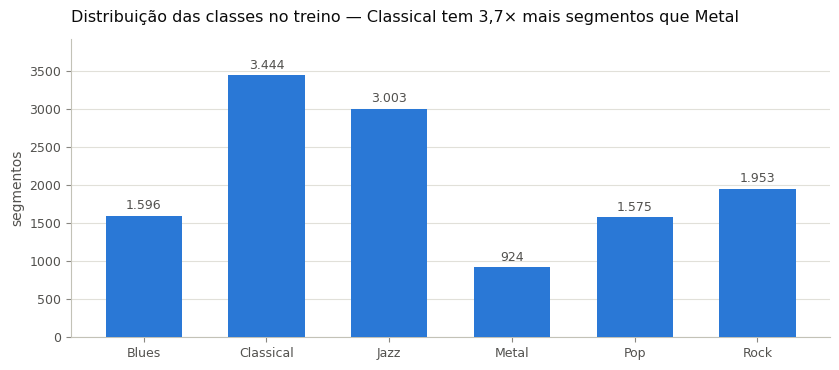

In [3]:
contagem = df_tr["GENRE"].value_counts().reindex(list(COD))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
barras = ax.bar(contagem.index, contagem.values, color=AZUL, width=0.62, zorder=3)
for b, v in zip(barras, contagem.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 45, f"{v:,}".replace(",", "."),
            ha="center", va="bottom", fontsize=9, color=TINTA_2)
estilizar(ax, "Distribuição das classes no treino — Classical tem 3,7× mais segmentos que Metal")
ax.set_ylabel("segmentos", color=TINTA_2)
ax.set_ylim(0, contagem.max() * 1.14)
plt.tight_layout()
plt.show()

## 2. Linha do tempo: todas as versões e seus resultados

| # | Versão | Abordagem | Validação local | Leaderboard | Lição |
|---|---|---|---|---|---|
| 1 | K-Means v1 | 191 features → escala → PCA → K-Means (voto majoritário por cluster) | 85,47% | — | teto do não supervisionado |
| 2 | K-Means v2 | + ~24 features de engenharia, log com sinal, winsorização; k=300 | 85,91% | — | pré-processamento cuidadoso rende pouco aqui |
| 3 | SVM (supervisionado) | comparação de 7 modelos; vence SVM RBF (C=10) | **97,60%** | **0,72814** | 💥 validação local **não é confiável** |
| 4 | — | diagnóstico: **validação adversarial** treino×teste | AUC ≈ 0,97 | — | *covariate shift* severo (gravações diferentes) |
| 5 | v3 (`submissao_pseudo`) | 40 features **DCT** + ensemble SVM+HistGB + **pseudo-rotulagem** (3 rodadas) | — | 0,78557 | desenhar para robustez, não para acurácia local |
| 6 | v4 | pseudo-rotulagem estendida (6 rodadas, ensemble triplo) + correção EM de *label shift* ao final | — | 0,79323 | os priors do teste diferem dos do treino |
| 7 | v5 | EM **dentro de cada rodada** + seleção com **cotas por classe** (alinhamento de distribuição) | — | 0,79642 → **1º lugar** | sem cotas, o prior do Metal colapsava |
| 8 | **v6 (final)** | **bagging** do processo v5: 4 execuções independentes, média das probabilidades | — | **0,80089** | médias de processos inteiros estabilizam o ganho |
| 9 | v7 | suavização das probs v6 por clusters finos no espaço "gravação" (multi-resolução, estilo vencedores ISMIS) | +1,02 p.p. no espelho local | 0,79514 ✗ | validação-espelho **não transfere** sob o shift real |
| 10 | v8 | processo v6 + 16 features de **geometria espectral** (`GEO_*`, seção 6.1) | SVM +0,08 p.p. | 0,79132 ✗ | features redundantes perturbam um ótimo delicado |
| 11 | v9 | processo v6 + **consenso de música na seleção de pseudo-rótulos** (clusters finos de gravação, limiar 0,60) | — | **0,81684** ✓ | informação de música transfere quando entra pelo **treino**, não pela saída |
| 12 | v10 | consenso multi-nível com fallback (k=5063/3544) | — | 0,81365 ✗ | só o nível fino funciona; clusters grossos são impuros demais |
| 13 | v11 | 2ª passada do laço (rodada 0 semeada pelas probs convergidas da v9) | — | 0,81748 ✓ | iteração consolida, mas converge rápido |
| 14 | v12 | média das probabilidades v9+v11 | — | 0,81620 ✗ | misturar passada velha dilui a nova |
| 15 | v13 | grupos **kNN-mútuo híbridos** (pureza 0,996) + peso maior p/ consenso + 8 membros — tudo validado ANTES em experimentos de pool | pool: acc consenso 0,97 | **0,82386** ✓✓ | validar a peça na "porta de seleção" antes de treinar |
| 16 | **v14 (final)** | fração-alvo estendida a **0,90** (validada: incrementos acertam 80-84%; 0,92+ colapsa e foi vetado) + professor = v13 | pool: acc incremento ~82% | **0,83024** ✓✓ | o teto de cada dial é mensurável antes de custar uma submissão |

O gráfico abaixo mostra a evolução no leaderboard — cada ponto é uma submissão real avaliada pelo Kaggle (incluindo as regressões v7/v8, mantidas por honestidade experimental):

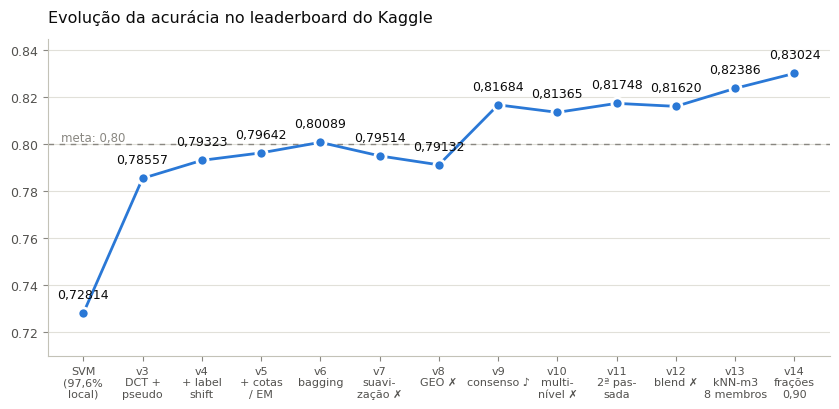

In [4]:
versoes = ["SVM\n(97,6%\nlocal)", "v3\nDCT +\npseudo", "v4\n+ label\nshift", "v5\n+ cotas\n/ EM", "v6\nbagging", "v7\nsuavi-\nzação ✗", "v8\nGEO ✗", "v9\nconsenso ♪", "v10\nmulti-\nnível ✗", "v11\n2ª pas-\nsada", "v12\nblend ✗", "v13\nkNN-m3\n8 membros", "v14\nfrações\n0,90"]
lb = [0.72814, 0.78557, 0.79323, 0.79642, 0.80089, 0.79514, 0.79132, 0.81684, 0.81365, 0.81748, 0.81620, 0.82386, 0.83024]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axhline(0.80, color=MUTED, linewidth=1, linestyle=(0, (4, 4)), zorder=2)
ax.text(-0.38, 0.8015, "meta: 0,80", color=MUTED, fontsize=8.5)
ax.plot(range(len(lb)), lb, color=AZUL, linewidth=2, zorder=3)
ax.plot(range(len(lb)), lb, "o", color=AZUL, markersize=8, zorder=4,
        markeredgecolor="white", markeredgewidth=2)
for i, v in enumerate(lb):
    ax.annotate(fmt_br(v, 5), (i, v), textcoords="offset points",
                xytext=(0, 11), ha="center", fontsize=9, color=TINTA)
estilizar(ax, "Evolução da acurácia no leaderboard do Kaggle")
ax.set_xticks(range(len(versoes)))
ax.set_xticklabels(versoes, fontsize=9)
ax.set_ylim(0.71, 0.845)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

## 3. Etapa 1 — abordagem não supervisionada (K-Means)

*Notebook original: `Classificacao_Generos_KMeans.ipynb` (v1 e v2).*

A primeira etapa do trabalho explorou até onde uma abordagem **não supervisionada** chega: agrupar os segmentos com K-Means e rotular cada cluster pelo **voto majoritário** dos rótulos de treino que caem nele.

**Pipeline da v2 (a melhor):**
1. **Engenharia de features (~24 novas `FE_*`):** agregados e inclinação das bandas ASE/SFM (desvio-padrão, amplitude, reta de tendência ao longo das bandas), razões grave/agudo, coeficientes de variação dos centroides espectrais e razões entre estatísticas de RMS.
2. **Log com sinal** nas colunas com |assimetria| > 2 (42 colunas): `sign(x)·log1p(|x|)`.
3. **Winsorização** nos quantis 0,5% / 99,5% — limites aprendidos **somente no treino** e aplicados ao teste (sem vazamento).
4. `StandardScaler` → **PCA a 95% da variância** (215 → 72 componentes).
5. **K-Means com k = 300** clusters; cada cluster prevê seu gênero majoritário.

**Resultado:** 85,91% de acurácia na validação (v1, sem FE e sem tratamento de outliers: 85,47%). O ganho do pré-processamento existiu, mas foi pequeno — e o método tem um teto natural: clusters de timbre não respeitam fronteiras de gênero (Rock e Metal se misturam; Jazz instrumental encosta em Classical).

**Papel na história:** estabeleceu a linha de base e todo o pré-processamento (FE + log + winsorização) que seria reaproveitado nas etapas seguintes.

## 4. Etapa 2 — modelos supervisionados (7 algoritmos)

*Notebook original: `Classificacao_Generos_Modelo_Avancado.ipynb`.*

Com o mesmo pré-processamento da v2 (**sem** PCA, que descarta informação útil para modelos supervisionados), foram comparados 7 algoritmos. Para que a validação cruzada fosse honesta quanto ao pré-processamento, o tratamento de outliers foi encapsulado num transformador sklearn (`TratadorOutliers`) dentro de um `Pipeline` — os limites de winsorização são re-aprendidos em cada *fold*, sem vazamento.

| Modelo | Acurácia (validação) |
|---|---|
| **SVM RBF** (C=10, gamma=scale) | **97,60%** (CV 5-fold: 97,47% ± 0,24%) |
| HistGradientBoosting | 96,0% |
| LightGBM | 95,8% |
| XGBoost | 95,0% |
| Extra Trees | 93,9% |
| Random Forest | 93,6% |
| KNN | 92,3% |

O SVM com kernel RBF venceu com folga — coerente com a natureza dos dados (features densas, contínuas, fronteiras suaves em alta dimensão). A submissão `submissao_svm.csv` foi enviada com confiança…

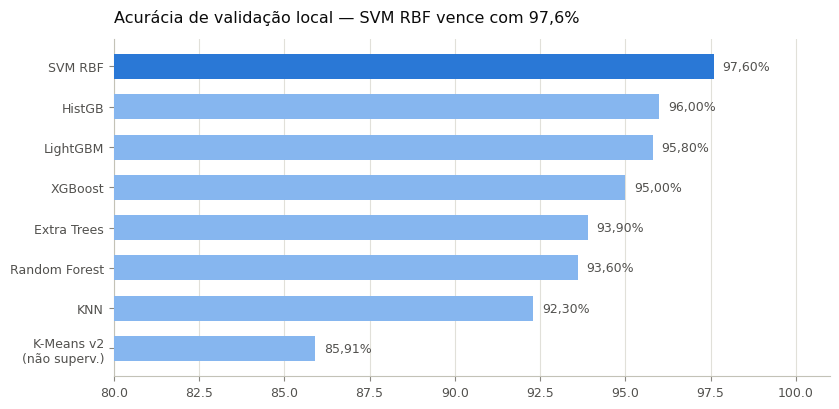

In [5]:
modelos_nomes = ["SVM RBF", "HistGB", "LightGBM", "XGBoost", "Extra Trees",
                 "Random Forest", "KNN", "K-Means v2\n(não superv.)"]
modelos_acc = [97.60, 96.0, 95.8, 95.0, 93.9, 93.6, 92.3, 85.91]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
pos = np.arange(len(modelos_nomes))[::-1]
cores = [AZUL] + [AZUL_CLARO] * (len(modelos_nomes) - 1)   # destaque no vencedor
ax.barh(pos, modelos_acc, color=cores, height=0.62, zorder=3)
for p, v in zip(pos, modelos_acc):
    ax.text(v + 0.25, p, fmt_br(v, 2) + "%", va="center", fontsize=9, color=TINTA_2)
estilizar(ax, "Acurácia de validação local — SVM RBF vence com 97,6%", grade="x")
ax.set_yticks(pos)
ax.set_yticklabels(modelos_nomes, fontsize=9)
ax.set_xlim(80, 101)
plt.tight_layout()
plt.show()

## 5. O choque do leaderboard e a validação adversarial

**`submissao_svm.csv` marcou 0,72814 no leaderboard — 25 pontos percentuais abaixo da validação local.** Não era *overfitting* clássico (a CV 5-fold era estável, ±0,24%). A hipótese: o **teste vem de uma distribuição diferente do treino** — *covariate shift*.

**Diagnóstico — validação adversarial.** A técnica é simples e poderosa: junte treino e teste, crie um rótulo binário "é do teste?" e treine um classificador. Se treino e teste vêm da mesma distribuição, o modelo não consegue distingui-los (AUC ≈ 0,5). A célula abaixo executa o diagnóstico ao vivo:

In [6]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score

feats = list(df_te.columns)                     # as 191 features originais
X_adv = pd.concat([df_tr[feats], df_te[feats]], ignore_index=True)
y_adv = np.r_[np.zeros(len(df_tr)), np.ones(len(df_te))]   # 0 = treino, 1 = teste

modelo_adv = LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=63,
                            random_state=42, n_jobs=-1, verbose=-1)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
prob_adv = cross_val_predict(modelo_adv, X_adv, y_adv, cv=cv,
                             method="predict_proba")[:, 1]
auc_adv = roc_auc_score(y_adv, prob_adv)
print(f"AUC da validação adversarial (treino × teste): {auc_adv:.3f}")
print("(0,5 = indistinguíveis; > 0,9 = covariate shift severo)")

# quais features mais denunciam a origem da amostra?
modelo_adv.fit(X_adv, y_adv)
importancias = pd.Series(modelo_adv.booster_.feature_importance("gain"),
                         index=feats).sort_values(ascending=False)

AUC da validação adversarial (treino × teste): 0.968
(0,5 = indistinguíveis; > 0,9 = covariate shift severo)


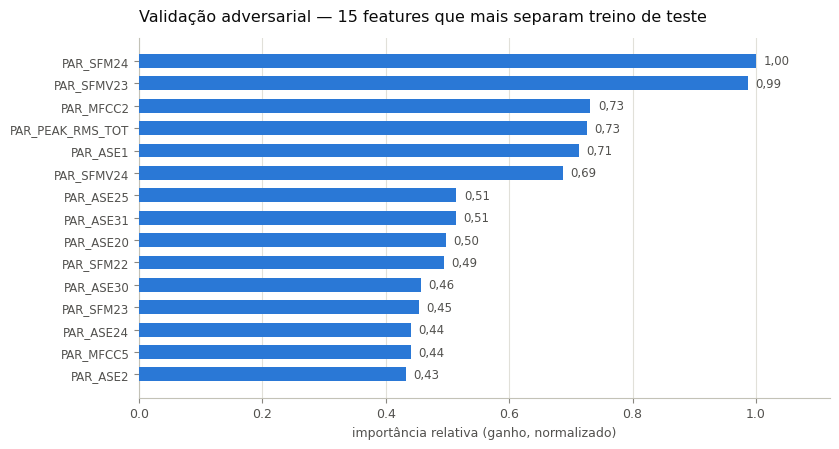

In [7]:
top = importancias.head(15) / importancias.max()

fig, ax = plt.subplots(figsize=(8.5, 4.6))
pos = np.arange(len(top))[::-1]
ax.barh(pos, top.values, color=AZUL, height=0.62, zorder=3)
for p, v in zip(pos, top.values):
    ax.text(v + 0.012, p, fmt_br(v, 2), va="center", fontsize=8.5, color=TINTA_2)
estilizar(ax, "Validação adversarial — 15 features que mais separam treino de teste", grade="x")
ax.set_yticks(pos)
ax.set_yticklabels(top.index, fontsize=8.5)
ax.set_xlabel("importância relativa (ganho, normalizado)", color=TINTA_2, fontsize=9)
ax.set_xlim(0, 1.12)
plt.tight_layout()
plt.show()

**Leitura dos resultados** (AUC ≈ 0,97 — *shift* severo):

- As features que mais separam treino de teste são de **timbre e condição de gravação**: `PAR_MFCC2` (inclinação espectral global — reflete equalização/masterização), bandas altas do envelope (`PAR_ASE20–32`) e da planura espectral (`PAR_SFM22–24`). O teste vem de **gravações e intérpretes diferentes** dos do treino.
- Pior: como vários segmentos vêm da **mesma gravação** e não há ID de música, qualquer divisão treino/validação local coloca segmentos da mesma gravação dos dois lados. O modelo "reconhece a gravação" em vez de reconhecer o gênero — por isso os 97,6% locais eram uma ilusão. **Nenhuma métrica local é confiável em valor absoluto** neste dataset.
- Tentativa de consertar a métrica: **ponderação por importância** (peso `w = p/(1−p)` da probabilidade adversarial, reavaliando a validação como se fosse o teste). Continuou otimista (~0,96) — o vazamento intra-gravação domina.

**Consequência metodológica para todo o resto do projeto:** o leaderboard passou a ser o único sinal honesto, e as decisões passaram a ser guiadas por **princípios de robustez** (usar representações invariantes à gravação, adaptar o modelo ao domínio do teste) em vez de otimização de métrica local.

## 6. Etapa 3 — atacando o shift: features DCT + pseudo-rotulagem (v3)

*Notebook original: `Classificacao_Generos_Espectral_Pseudo.ipynb` → `submissao_pseudo.csv` = **0,78557** (2º lugar na época).*

Duas frentes de ataque, ambas motivadas pelo diagnóstico da seção 5:

**(a) Representação mais invariante — coeficientes DCT sobre as bandas espectrais.**
O mesmo princípio dos MFCCs: aplicar a **DCT-II ao longo das bandas** de ASE/ASEV/SFM/SFMV comprime a *forma* do espectro em coeficientes ordenados do padrão grosso (baixa ordem) ao detalhe fino (alta ordem). Os coeficientes de baixa ordem descrevem "como a energia se distribui do grave ao agudo" — característica de **gênero** — e são menos sensíveis a deslocamentos finos de banda causados pela gravação. São retidos 10 coeficientes × 4 grupos = **40 features `DCT_*`**.

**(b) Adaptação de domínio — pseudo-rotulagem (self-training).**
Se o teste vem de outra distribuição, a saída é **deixar o modelo aprender com o próprio teste**: prever o teste, incorporar as previsões mais confiantes como exemplos de treino (com peso reduzido) e re-treinar, iterativamente. Na v3: ensemble SVM (0,6) + HistGB (0,4) com probabilidades, 3 rodadas, limiar de confiança 0,90, peso 0,7.

As células abaixo definem o pipeline de features completo (o mesmo usado da v3 à v6) e o executam:

In [8]:
# ------------------------- pipeline de features (v3 -> v6) -------------------------
EPS = 1e-9
COLS_ASE  = [f"PAR_ASE{i}"  for i in range(1, 35)]
COLS_ASEV = [f"PAR_ASEV{i}" for i in range(1, 35)]
COLS_SFM  = [f"PAR_SFM{i}"  for i in range(1, 25)]
COLS_SFMV = [f"PAR_SFMV{i}" for i in range(1, 25)]
COLS_MFCC  = [f"PAR_MFCC{i}"  for i in range(1, 21)]
COLS_MFCCV = [f"PAR_MFCCV{i}" for i in range(1, 21)]


def inclinacao_bandas(m):
    """Coeficiente angular de uma reta ajustada ao perfil de bandas (tendência grave->agudo)."""
    x = np.arange(m.shape[1])
    return np.polyfit(x, m.T, 1)[0]


def coeficientes_dct(matriz, n_coefs, log=False):
    """DCT-II ao longo das bandas: descreve a FORMA do espectro em coeficientes
    ordenados do padrão grosso (baixa ordem) ao detalhe fino (alta ordem)."""
    m = np.log1p(np.abs(matriz)) * np.sign(matriz) if log else matriz
    return dct(m, type=2, axis=1, norm="ortho")[:, :n_coefs]


# ---------------- geometria espectral contínua (GEO_*, seção 6.1) ----------------

def densidade_espectral(matriz, n_grade=PARAMS["N_GRADE_GEO"]):
    """Converte cada linha em densidade contínua p(x) >= 0 com ∫p dx = 1 em [0,1].
    1) desloca ao mínimo da linha (invariância a volume/masterização);
    2) PCHIP: cúbica monótona por trechos — sem oscilações de Runge;
    3) normaliza pela integral de Simpson (erro O(h^4)).
    Todas as operações são POR LINHA -> zero vazamento por construção."""
    n, b = matriz.shape
    x0, xg = np.linspace(0, 1, b), np.linspace(0, 1, n_grade)
    e = np.nan_to_num(matriz.astype(np.float64) - np.nanmin(matriz, axis=1, keepdims=True))
    pch = PchipInterpolator(x0, e, axis=1)
    pg = np.clip(np.nan_to_num(pch(xg)), 0.0, None)
    dg = np.nan_to_num(pch.derivative()(xg))
    Z = simpson(pg, x=xg, axis=1)
    quase_nulo = Z < 1e-12                       # espectro ~constante -> uniforme
    if quase_nulo.any():
        pg[quase_nulo], dg[quase_nulo] = 1.0, 0.0
        Z = simpson(pg, x=xg, axis=1)
    return xg, pg / Z[:, None], dg / Z[:, None]


def interp_por_linha(xg, M, q):
    """Interpolação linear de M[i, :] (função na grade xg) no ponto q[i]."""
    pos = np.clip(np.searchsorted(xg, q) - 1, 0, len(xg) - 2)
    t = np.clip((q - xg[pos]) / (xg[pos + 1] - xg[pos]), 0.0, 1.0)
    fila = np.arange(M.shape[0])
    return M[fila, pos] + t * (M[fila, pos + 1] - M[fila, pos])


def quantil_espectral(xg, p, F, alpha, max_newton=12, tol=1e-4):
    """Resolve F(q) = alpha (F(q) = ∫_0^q p dx) por linha.
    Newton-Raphson vetorizado (F' = p): q <- q - (F(q) - alpha)/p(q).
    Fallback por BISSEÇÃO quando Newton sai de [0,1], acha p(q) ~ 0 ou não
    converge — F é monótona, então a bisseção sempre fecha o intervalo."""
    q = np.full(p.shape[0], 0.5)
    estavel = np.ones(p.shape[0], bool)
    for _ in range(max_newton):
        Fq, pq = interp_por_linha(xg, F, q), interp_por_linha(xg, p, q)
        q_novo = q - (Fq - alpha) / np.maximum(pq, 1e-9)
        ruim = (~np.isfinite(q_novo)) | (q_novo < 0) | (q_novo > 1) | (pq < 1e-6)
        estavel &= ~ruim
        q = np.where(estavel, np.clip(q_novo, 0.0, 1.0), q)
    falhou = (~estavel) | (np.abs(interp_por_linha(xg, F, q) - alpha) > tol)
    if falhou.any():
        Ff = F[falhou]
        lo, hi = np.zeros(falhou.sum()), np.ones(falhou.sum())
        for _ in range(40):                       # 2^-40 de precisão: sobra
            mid = 0.5 * (lo + hi)
            abaixo = interp_por_linha(xg, Ff, mid) < alpha
            lo, hi = np.where(abaixo, mid, lo), np.where(abaixo, hi, mid)
        q[falhou] = 0.5 * (lo + hi)
    return q


def geometria_espectral(matriz, prefixo):
    """Momentos e quantis (via Simpson + Newton/bisseção) da densidade de cada linha."""
    xg, p, dp = densidade_espectral(matriz)
    dx = xg[None, :]
    mu = simpson(p * dx, x=xg, axis=1)                          # centroide
    desvio = np.sqrt(np.clip(simpson(p * (dx - mu[:, None])**2, x=xg, axis=1), 0, None))
    m3 = simpson(p * (dx - mu[:, None])**3, x=xg, axis=1)
    F = cumulative_simpson(p, x=xg, axis=1, initial=0.0)
    F = F / np.maximum(F[:, -1:], 1e-12)                        # F(1) = 1
    q25 = quantil_espectral(xg, p, F, 0.25)
    q75 = quantil_espectral(xg, p, F, 0.75)
    feats = {f"GEO_{prefixo}_CENTROIDE": mu,
             f"GEO_{prefixo}_DESVIO": desvio,
             f"GEO_{prefixo}_ASSIMETRIA": m3 / np.maximum(desvio**3, 1e-9),
             f"GEO_{prefixo}_ENTROPIA": -simpson(p * np.log(p + 1e-12), x=xg, axis=1),
             f"GEO_{prefixo}_PICO": xg[p.argmax(axis=1)],       # moda da densidade
             f"GEO_{prefixo}_VARIACAO_TOTAL": simpson(np.abs(dp), x=xg, axis=1),
             f"GEO_{prefixo}_MEDIANA": quantil_espectral(xg, p, F, 0.50),
             f"GEO_{prefixo}_IQR": q75 - q25}
    return {k: np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0) for k, v in feats.items()}


def criar_features(df, com_dct=True, n_dct=PARAMS["N_DCT"], com_geo=None):
    novo = df.copy()
    ase, asev = df[COLS_ASE].values, df[COLS_ASEV].values
    sfm, sfmv = df[COLS_SFM].values, df[COLS_SFMV].values
    mfcc, mfccv = df[COLS_MFCC].values, df[COLS_MFCCV].values

    # agregados e forma do envelope espectral (ASE)
    novo["FE_ASE_STD"] = ase.std(axis=1)
    novo["FE_ASE_AMPLITUDE"] = ase.max(axis=1) - ase.min(axis=1)
    novo["FE_ASE_INCLINACAO"] = inclinacao_bandas(ase)
    grave, media, aguda = ase[:, :11].mean(1), ase[:, 11:23].mean(1), ase[:, 23:].mean(1)
    novo["FE_ASE_GRAVE"], novo["FE_ASE_MEDIA"], novo["FE_ASE_AGUDA"] = grave, media, aguda
    novo["FE_ASE_GRAVE_AGUDO"] = grave / (aguda + np.sign(aguda) * EPS + EPS)
    novo["FE_ASEV_STD"] = asev.std(axis=1)
    novo["FE_ASEV_INCLINACAO"] = inclinacao_bandas(asev)
    # planura espectral (SFM)
    novo["FE_SFM_STD"] = sfm.std(axis=1)
    novo["FE_SFM_INCLINACAO"] = inclinacao_bandas(sfm)
    sg, sm, sa = sfm[:, :8].mean(1), sfm[:, 8:16].mean(1), sfm[:, 16:].mean(1)
    novo["FE_SFM_GRAVE"], novo["FE_SFM_MEDIA"], novo["FE_SFM_AGUDA"] = sg, sm, sa
    novo["FE_SFM_GRAVE_AGUDO"] = sg / (sa + EPS)
    # timbre (MFCC) e instabilidade temporal
    novo["FE_MFCC_STD"] = mfcc.std(axis=1)
    novo["FE_MFCCV_MEDIA"] = mfccv.mean(axis=1)
    novo["FE_MFCC_INSTABILIDADE"] = mfccv.mean(1) / (np.abs(mfcc).mean(1) + EPS)
    # coeficientes de variação dos centroides e razões de RMS/TCD
    novo["FE_SC_CV"] = df["PAR_SC_V"] / (df["PAR_SC"].abs() + EPS)
    novo["FE_ASC_CV"] = df["PAR_ASC_V"] / (df["PAR_ASC"].abs() + EPS)
    novo["FE_ASS_CV"] = df["PAR_ASS_V"] / (df["PAR_ASS"].abs() + EPS)
    novo["FE_THR21"] = df["PAR_THR_2RMS_TOT"] / (df["PAR_THR_1RMS_TOT"] + EPS)
    novo["FE_THR31"] = df["PAR_THR_3RMS_TOT"] / (df["PAR_THR_1RMS_TOT"] + EPS)
    novo["FE_TCD31"] = df["PAR_3RMS_TCD"] / (df["PAR_1RMS_TCD"] + EPS)

    if com_dct:
        for nome, matriz, log in [("ASE", ase, False), ("ASEV", asev, True),
                                  ("SFM", sfm, False), ("SFMV", sfmv, True)]:
            n = min(n_dct, matriz.shape[1])
            coefs = coeficientes_dct(matriz, n, log=log)
            for j in range(n):
                novo[f"DCT_{nome}_{j}"] = coefs[:, j]

    if com_geo is None:
        com_geo = PARAMS["USAR_GEOMETRIA_ESPECTRAL"]
    if com_geo:
        for prefixo, matriz in [("ASE", ase), ("SFM", sfm)]:
            for nome, valores in geometria_espectral(matriz, prefixo).items():
                novo[nome] = valores
    return novo


def ajustar_tratamento(X_tr, skew_limite=PARAMS["SKEW_LIMITE"], quantis=PARAMS["QUANTIS_WINSOR"]):
    """Aprende NO TREINO: quais colunas recebem log com sinal e os limites de winsorização."""
    skew = X_tr.skew()
    cols = skew[skew.abs() > skew_limite].index.tolist()
    X_log = X_tr.copy()
    for c in cols:
        X_log[c] = np.sign(X_log[c]) * np.log1p(np.abs(X_log[c]))
    return cols, X_log.quantile(quantis[0]), X_log.quantile(quantis[1])


def aplicar_tratamento(X, cols, li, ls):
    X = X.copy()
    for c in cols:
        X[c] = np.sign(X[c]) * np.log1p(np.abs(X[c]))
    return X.clip(li, ls, axis=1)

In [9]:
X_fe = criar_features(df_tr.drop(columns=["GENRE"]))
X_te_fe = criar_features(df_te)
cols_log, lim_inf, lim_sup = ajustar_tratamento(X_fe)

n_fe = sum(c.startswith("FE_") for c in X_fe.columns)
n_dct = sum(c.startswith("DCT_") for c in X_fe.columns)
n_geo = sum(c.startswith("GEO_") for c in X_fe.columns)
print(f"Features: 191 originais + {n_fe} FE_* + {n_dct} DCT_* + {n_geo} GEO_* = {X_fe.shape[1]}")
print(f"Colunas com log com sinal (|skew| > {PARAMS['SKEW_LIMITE']}): {len(cols_log)}")

Features: 191 originais + 24 FE_* + 40 DCT_* + 0 GEO_* = 255
Colunas com log com sinal (|skew| > 2.0): 42


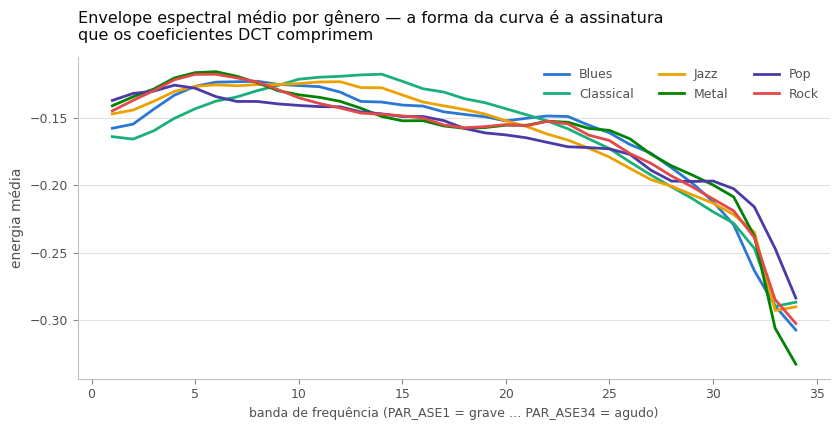

In [10]:
# A motivação visual das features DCT: cada gênero tem uma FORMA característica
# de distribuição de energia ao longo das 34 bandas do envelope espectral.
medias_ase = df_tr.groupby("GENRE")[COLS_ASE].mean()

fig, ax = plt.subplots(figsize=(8.5, 4.4))
for genero in COD:
    ax.plot(range(1, 35), medias_ase.loc[genero], color=CORES_GENEROS[genero],
            linewidth=2, label=genero, zorder=3)
estilizar(ax, "Envelope espectral médio por gênero — a forma da curva é a assinatura\n"
              "que os coeficientes DCT comprimem")
ax.set_xlabel("banda de frequência (PAR_ASE1 = grave … PAR_ASE34 = agudo)",
              color=TINTA_2, fontsize=9)
ax.set_ylabel("energia média", color=TINTA_2)
ax.legend(frameon=False, fontsize=9, ncol=3, labelcolor=TINTA_2)
plt.tight_layout()
plt.show()

### 6.1 Geometria espectral contínua (features `GEO_*`)

Extensão da mesma tese da DCT — descrever a **forma** do espectro, não seus valores brutos — agora pela via do cálculo numérico: cada vetor de bandas (ASE com 34 bandas, SFM com 24) é tratado como uma **distribuição contínua de energia** `p(x)` ao longo da frequência normalizada `x ∈ [0, 1]`:

1. **Normalização por linha** — a curva é deslocada ao próprio mínimo e reescalada para `∫p dx = 1`. Isso remove nível absoluto (volume, masterização, estúdio) por construção; sobra só a *forma*.
2. **Interpolação PCHIP** (cúbica de Hermite monótona por trechos) transforma as bandas discretas em curva contínua **sem as oscilações artificiais** que um polinômio global de grau 33 criaria (fenômeno de Runge).
3. **Integração de Simpson** (erro `O(h⁴)`) numa grade de 201 pontos calcula os momentos da distribuição: **centroide** `∫x·p dx`, **desvio**, **assimetria** (3º momento normalizado), **entropia** `−∫p·ln p dx`, **posição do pico** (moda) e **variação total** `∫|p′| dx` (rugosidade da curva).
4. **Mediana e quartis** resolvem `∫₀^q p dx = α` por **Newton-Raphson** (a derivada é a própria densidade: `F′ = p`) com **fallback de bisseção** quando Newton sai de `[0,1]` ou encontra `p(q) ≈ 0` — como `F` é monótona, a bisseção sempre converge.

São **16 features** (8 por família × ASE/SFM), todas calculadas **linha a linha** — nenhuma estatística cruza amostras, logo zero risco de vazamento. Chave de ativação: `PARAMS["USAR_GEOMETRIA_ESPECTRAL"]`.

**Resultados do experimento comparativo** (script `experimento_geo.py`):

| Métrica | baseline (255 feats) | + geometria (271) |
|---|---|---|
| AUC adversarial do conjunto | 0,969 | 0,969 (não adiciona shift) |
| AUC adversarial das GEO_* isoladas | — | **0,858** (bem mais invariantes que as brutas) |
| SVM RBF, split por pseudo-música (2 folds) | 0,9337 / 0,9497 | **0,9345 / 0,9505** (+0,08 p.p. nos dois) |
| HGB, mesmo split | 0,9258 / 0,9244 | 0,9237 / 0,9227 (−0,2 p.p.) |

Leitura na época: ganho pequeno e consistente no SVM, leve perda no HGB, e features menos "contaminadas" pela gravação que o restante do conjunto.

**Veredito do leaderboard: a v8 (processo v6 completo + GEO) marcou 0,79132 — 0,96 p.p. ABAIXO da v6.** Mesmo matematicamente bem construídas e mais invariantes ao shift, as features eram *redundantes* com a informação de forma espectral que FE_*/DCT_* já capturam — e perturbar a representação de um pipeline num ótimo delicado moveu exatamente as previsões de margem que decidem o placar. O bloco fica documentado (e desligável por `PARAMS["USAR_GEOMETRIA_ESPECTRAL"] = False`, o padrão atual) como o experimento que ensinou essa lição.

In [11]:
# Estatísticas das features geométricas e teste de invariância (AUC adversarial isolada).
# Como a chave está desligada no pipeline (lição da v8), calculamos as GEO_* aqui só p/ análise.
geo_tr = pd.DataFrame({**geometria_espectral(df_tr[COLS_ASE].values, "ASE"),
                       **geometria_espectral(df_tr[COLS_SFM].values, "SFM")})
geo_te = pd.DataFrame({**geometria_espectral(df_te[COLS_ASE].values, "ASE"),
                       **geometria_espectral(df_te[COLS_SFM].values, "SFM")})
geo_cols = list(geo_tr.columns)
print(f"{len(geo_cols)} features GEO_*:\n")
print(geo_tr.describe().T[["mean", "std", "min", "50%", "max"]].round(4).to_string())
assert np.isfinite(geo_tr.values).all() and np.isfinite(geo_te.values).all()

X_adv_geo = pd.concat([geo_tr, geo_te], ignore_index=True)
prob_geo = cross_val_predict(LGBMClassifier(n_estimators=200, learning_rate=0.1,
                                            num_leaves=63, random_state=42, n_jobs=-1,
                                            verbose=-1),
                             X_adv_geo, y_adv, cv=cv, method="predict_proba")[:, 1]
print(f"\nAUC adversarial só com as GEO_*: {roc_auc_score(y_adv, prob_geo):.3f} "
      f"(conjunto completo: {auc_adv:.3f} -> as GEO_* são as features mais invariantes ao shift)")

16 features GEO_*:

                           mean     std     min      50%      max
GEO_ASE_CENTROIDE        0.4258  0.0266  0.2572   0.4287   0.5429
GEO_ASE_DESVIO           0.2549  0.0143  0.1964   0.2564   0.2906
GEO_ASE_ASSIMETRIA       0.1946  0.1201 -0.4615   0.1741   1.2073
GEO_ASE_ENTROPIA        -0.0807  0.0390 -0.3953  -0.0723  -0.0109
GEO_ASE_PICO             0.2515  0.1350  0.0000   0.2450   0.7900
GEO_ASE_VARIACAO_TOTAL   2.5210  0.7232  1.4509   2.3866  20.3665
GEO_ASE_MEDIANA          0.4089  0.0347  0.1832   0.4121   0.5695
GEO_ASE_IQR              0.4206  0.0390  0.2662   0.4238   0.5207
GEO_SFM_CENTROIDE        0.5237  0.0316  0.3210   0.5225   0.7057
GEO_SFM_DESVIO           0.3008  0.0138  0.2215   0.2990   0.3706
GEO_SFM_ASSIMETRIA      -0.2021  0.1595 -1.2632  -0.1920   1.0540
GEO_SFM_ENTROPIA        -0.1149  0.0406 -0.5052  -0.1055  -0.0510
GEO_SFM_PICO             0.0150  0.1129  0.0000   0.0000   1.0000
GEO_SFM_VARIACAO_TOTAL  12.8930  1.9760  7.8258  12.6840


AUC adversarial só com as GEO_*: 0.858 (conjunto completo: 0.968 -> as GEO_* são as features mais invariantes ao shift)


## 7. v4 — correção de *label shift* (EM de Saerens) → LB 0,79323

Além do *covariate shift*, havia um segundo desalinhamento: a **proporção de cada gênero no teste não é a mesma do treino** (*label shift* / *prior shift*). Um classificador treinado com os priors do treino distorce sistematicamente as probabilidades quando os priors do alvo mudam.

A correção clássica é o **algoritmo EM de Saerens (2002)**: re-estimar iterativamente os priors do teste a partir das próprias probabilidades previstas, reescalando-as a cada passo:

1. **E:** `P'(y|x) ∝ P(y|x) · π_novo(y) / π_treino(y)`, renormalizado por linha;
2. **M:** `π_novo(y) = média de P'(y|x)` sobre o teste;
3. repetir até convergir (com um piso `PRIOR_MINIMO` para nenhuma classe colapsar a zero).

Na **v4**, a pseudo-rotulagem foi estendida (6 rodadas, limiar 0,88, ensemble triplo **SVM 0,5 + HistGB 0,3 + LightGBM 0,2**) e a correção EM foi aplicada **uma única vez, ao final**, sobre as probabilidades da última rodada. Resultado: **0,79323** (+0,77 p.p. sobre a v3).

In [12]:
def corrigir_label_shift(prob, prior_treino, prior_minimo=PARAMS["PRIOR_MINIMO"]):
    """EM de Saerens: re-estima os priors do teste e reescala P(y|x).
    prob: matriz (n_amostras × n_classes); prior_treino: priors do conjunto que treinou o modelo."""
    prior = prior_treino.copy()
    for _ in range(30):
        prob_aj = prob * (prior / prior_treino)          # passo E: reescala
        prob_aj /= prob_aj.sum(axis=1, keepdims=True)
        prior_novo = np.clip(prob_aj.mean(axis=0), prior_minimo, None)  # passo M
        prior_novo /= prior_novo.sum()
        if np.abs(prior_novo - prior).max() < 1e-6:      # convergiu
            break
        prior = prior_novo
    return prob_aj, prior

print("Função de correção de label shift definida (usada da v4 em diante).")

Função de correção de label shift definida (usada da v4 em diante).


## 8. v5 — EM dentro do laço + alinhamento de distribuição → LB 0,79642 (1º lugar)

A v5 nasceu de um defeito observado na v4: aplicar o EM só **ao final** deixa todas as rodadas intermediárias de pseudo-rotulagem operarem com probabilidades distorcidas — e a seleção "pegue os mais confiantes acima do limiar" tem um **viés de composição** perverso. Classes fáceis (Classical) geram confianças altíssimas e dominam os pseudo-rótulos; classes difíceis e raras (Metal) quase não entram. A cada rodada o desequilíbrio se **auto-reforça**: monitorando o processo, o prior estimado do Metal colapsava de 1,9% para 0,8%.

Duas mudanças estruturais:

1. **Correção EM dentro de cada rodada** — as probabilidades são corrigidas *antes* da seleção de pseudo-rótulos. Detalhe importante descoberto na prática: o EM deve usar os priors do **conjunto de treino atual da rodada** (treino original + pseudo-rótulos já incorporados, ponderados pelos pesos amostrais), não os priors originais — os pseudo-rótulos já deslocam a distribuição, e usar os priors originais super-corrige.
2. **Seleção com alinhamento de distribuição (estilo FixMatch)** — em vez de um limiar global, cada classe recebe uma **cota**: os `n_c` pseudo-rótulos mais confiantes da classe `c`, com `n_c ∝ prior estimado da classe`. Isso força a composição dos pseudo-rótulos a seguir a distribuição estimada do teste. Mesmo com o EM dentro do laço, sem as cotas o colapso persistia — as duas peças são complementares.

**Receita completa da v5:** 8 rodadas; fração-alvo do teste incorporada crescendo de 60% a 85%; piso de confiança 0,70; peso amostral do pseudo-rótulo = 0,8 × confiança corrigida; previsão final = **média das probabilidades corrigidas das 3 últimas rodadas** (suaviza a variância entre rodadas). O processo convergiu de forma saudável: prior do Metal estável (1,9% → 2,5%), previsões mudando cada vez menos entre rodadas (248 → 68).

**`submissao_v5.csv` = 0,79642 → 1º lugar do leaderboard** (diferia em 152 previsões, 2,9%, da v4).

## 9. v6 — *bagging* do processo completo → LB **0,80089**

Faltavam ~0,4 p.p. para a meta de 0,80. A pseudo-rotulagem é um processo com variância: semente, subamostra e hiperparâmetros mudam quais pseudo-rótulos entram nas primeiras rodadas, e essas escolhas se propagam. Se cada execução completa é uma amostra ruidosa em torno da "resposta certa", **a média de várias execuções independentes deve ser melhor que qualquer uma delas** — *bagging*, aplicado não a um modelo, mas ao **processo inteiro** da v5.

**Os 4 membros do comitê:**

| Membro | Semente | C (SVM) | num_leaves (LGBM) | Subamostra do treino | Rodadas |
|---|---|---|---|---|---|
| v5 original | 42 | 10 | 63 | 100% | 8 |
| bag 1 | 42 | 10 | 63 | 90% estratificada | 6 |
| bag 2 | 7 | 12 | 47 | 90% estratificada | 6 |
| bag 3 | 2026 | 8 | 95 | 90% estratificada | 6 |

Cada membro executa o processo v5 completo (pseudo-rotulagem com EM na rodada + cotas) e entrega a média das probabilidades corrigidas de suas 3 últimas rodadas. A **previsão final é a média das probabilidades dos 4 membros**.

Diagnósticos na geração: **94,1% de unanimidade** entre os 4 membros (o desacordo se concentra exatamente nas amostras difíceis, onde a média ajuda); a v6 difere da v5 em apenas 95 previsões (1,8%) — e essa pequena correção rendeu **+0,45 p.p.: 0,80089, meta batida**.

A célula abaixo contém o pipeline final completo e auto-suficiente. Por padrão (`EXECUTAR_PIPELINE_FINAL = False`) ela não re-executa o treinamento (~26 rodadas de SVM + HistGB + LightGBM, horas de processamento); os scripts originais estão em `solucao_final/`.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier


def treinar_ensemble(X, yy, w, seed, c_svm, folhas):
    svm = SVC(C=c_svm, gamma="scale", probability=True, random_state=seed, cache_size=800)
    hgb = HistGradientBoostingClassifier(max_iter=300, random_state=seed)
    lgb = LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=folhas,
                         random_state=seed, n_jobs=-1, verbose=-1)
    svm.fit(X, yy, sample_weight=w)
    hgb.fit(X, yy, sample_weight=w)
    lgb.fit(X, yy, sample_weight=w)
    return svm, hgb, lgb


def prob_ensemble(modelos, X):
    svm, hgb, lgb = modelos
    a, b, c = PARAMS["PESOS_ENSEMBLE"]
    # alinha a ordem das classes do LightGBM à do SVM antes de combinar
    p_lgb = lgb.predict_proba(X)[:, [list(lgb.classes_).index(cl) for cl in svm.classes_]]
    return a * svm.predict_proba(X) + b * hgb.predict_proba(X) + c * p_lgb


def executar_membro(seed, c_svm, folhas, frac_bag, fracoes):
    """Processo v5 completo para um membro: pseudo-rotulagem iterativa com correção EM
    dentro de cada rodada e seleção com cotas por classe. Devolve a média das
    probabilidades corrigidas das N_MEDIA_RODADAS últimas rodadas."""
    if frac_bag < 1.0:   # subamostra estratificada (bagging), determinística pela semente
        idx_bag, _ = train_test_split(np.arange(len(y)), train_size=frac_bag,
                                      stratify=y, random_state=seed)
    else:
        idx_bag = np.arange(len(y))
    X_bag, y_bag = X_fe.iloc[idx_bag], y[idx_bag]

    cols, li, ls = ajustar_tratamento(X_bag)
    A = aplicar_tratamento(X_bag, cols, li, ls)
    B = aplicar_tratamento(X_te_fe, cols, li, ls)
    sc = StandardScaler()
    A, B = sc.fit_transform(A), sc.transform(B)

    X_atual, y_atual, w_atual = A, y_bag, np.ones(len(y_bag))
    historico = []
    for r, fracao in enumerate(fracoes):
        modelos = treinar_ensemble(X_atual, y_atual, w_atual, seed, c_svm, folhas)
        classes = modelos[0].classes_
        # priors do treino ATUAL da rodada, ponderados pelos pesos amostrais
        pt = pd.Series(w_atual).groupby(pd.Series(y_atual)).sum()
        pt = (pt / pt.sum()).reindex(classes).values

        prob_aj, prior_est = corrigir_label_shift(prob_ensemble(modelos, B), pt)
        pred, conf = classes[prob_aj.argmax(1)], prob_aj.max(1)
        historico = (historico + [prob_aj])[-PARAMS["N_MEDIA_RODADAS"]:]

        # seleção com alinhamento de distribuição: cota por classe ∝ prior estimado
        n_alvo = fracao * len(B)
        sel = np.concatenate([
            (idx_c := np.where((pred == c) & (conf >= PARAMS["CONF_MINIMA"]))[0])
            [np.argsort(-conf[idx_c])[:int(round(prior_est[i] * n_alvo))]]
            for i, c in enumerate(classes)])
        print(f"  [seed {seed}] rodada {r}: pseudo aceitos = {len(sel)}/5225 | "
              f"conf média = {conf.mean():.3f}", flush=True)

        X_atual = np.vstack([A, B[sel]])
        y_atual = np.r_[y_bag, pred[sel]]
        w_atual = np.r_[np.ones(len(y_bag)), PARAMS["PESO_BASE"] * conf[sel]]

    return np.mean(historico, axis=0), classes


if PARAMS["EXECUTAR_PIPELINE_FINAL"]:
    membros = []
    print("Membro v5 (dados completos, 8 rodadas):")
    p, classes_ref = executar_membro(42, 10, 63, 1.00, PARAMS["FRACOES_V5"])
    membros.append(p)
    for seed, c_svm, folhas, frac in PARAMS["CONFIGS_BAGGING"]:
        print(f"Membro bagging seed={seed}:")
        p, _ = executar_membro(seed, c_svm, folhas, frac, PARAMS["FRACOES_V6"])
        membros.append(p)

    prob_final = np.mean(membros, axis=0)
    pred_final = np.asarray(classes_ref)[prob_final.argmax(1)]
    sub = pd.DataFrame({"Id": np.arange(1, 5226),
                        "Genres": [COD[g] for g in pred_final]})
    sub.to_csv(PARAMS["PASTA"] + r"\submissao_v6.csv", index=False)
    print("'submissao_v6.csv' regenerada.")
else:
    print("EXECUTAR_PIPELINE_FINAL = False -> usando a 'submissao_v6.csv' já gerada "
          "(LB 0,80089).\nPara reproduzir do zero, mude a chave em PARAMS (~horas de execução).")

EXECUTAR_PIPELINE_FINAL = False -> usando a 'submissao_v6.csv' já gerada (LB 0,80089).
Para reproduzir do zero, mude a chave em PARAMS (~horas de execução).


### 9.2 v9 — consenso de música na seleção de pseudo-rótulos → LB **0,81684** (recorde)

Depois que v7 e v8 falharam (seção 10), a análise das três evidências apontou o caminho: **neste projeto, ganhos só transferiram para o leaderboard quando entraram pela seleção de pseudo-rótulos** — nunca pelo pós-processamento da saída (v7) nem pela representação (v8). Os vencedores da competição original (Schierz/Budka, 87,5%) usavam a estrutura segmento→música re-rotulando *clusters* e **re-treinando**, iterativamente. A v9 traduz esse mecanismo para o nosso pipeline, tocando num único ponto:

- **Clusters finos de gravação:** K-Means com k = n/2,5 (7.088 clusters, ~2,5 segmentos) sobre treino+teste no espaço **bruto** padronizado + PCA 95% — o espaço onde a "impressão digital da gravação" vive (a mesma que sabotava a validação local, agora usada a favor). Pureza de gênero no treino: 0,990.
- **Consenso de música na seleção:** em cada rodada de pseudo-rotulagem, um segmento de teste pode entrar no treino pelo consenso do seu cluster — se a probabilidade média dos **colegas de teste** aponta uma classe com confiança ≥ **0,60**, o segmento herda esse rótulo e essa confiança (piso de entrada = 0,60 para consenso; 0,70 para candidatos individuais). Cotas por classe, EM na rodada, ensemble triplo e bagging de 4 membros: **inalterados**.
- Detalhe de calibração que importou: com limiar de consenso 0,80 o mecanismo quase não agia (2–10 "resgates" por rodada); com 0,60, ~**2/3 de todos os pseudo-rótulos aceitos** passaram a entrar via consenso.

**Resultado: 0,81684 — +1,6 p.p. sobre a v6, o maior ganho desde a v3.** O interessante é *de onde* veio o ganho: os "resgates" (segmentos cujo rótulo individual foi vencido pelo consenso) continuaram raros; o efeito dominante foi a **moldagem da confiança do pool de treino** — segmentos coerentes com sua música entram mais cedo e com mais peso, e o modelo re-treinado aprende fronteiras alinhadas à estrutura de música em vez de a segmentos isolados. Diff vs v6: 190 previsões (3,6%); unanimidade entre membros: 95,0%; prior do Metal estável (~2,2%) em todas as 26 rodadas. Script: `solucao_final/gerar_v9.py`.

A série v10→v13 refinou o mecanismo por tentativas controladas, cada uma mudando UMA peça:

- **v10 (0,81365 ✗):** consenso estendido a níveis de cluster mais grossos (k=5063/3544) com fallback — regrediu. Clusters maiores no espaço K-Means misturam gêneros demais; **só o nível fino funciona**.
- **v11 (0,81748 ✓):** 2ª passada do laço — a rodada 0 de cada membro parte semeada com as probabilidades convergidas da v9 (a realimentação literal dos vencedores do ISMIS). Ganho pequeno (+0,06 p.p.): a iteração consolida (unanimidade 95→97%), mas converge rápido.
- **v12 (0,81620 ✗):** média das probabilidades v9+v11 — misturar a passada velha com a nova dilui.
- **v13 (0,82386 ✓✓, +0,64 p.p.):** três melhorias **validadas em experimentos de pool antes do treino** (`experimento_clusters_v13.py` / `experimento_pool_v13.py`): (i) grupos de música **híbridos** — componentes do grafo kNN-mútuo k=3 (pureza de gênero 0,996 no treino, acima dos 0,986 do K-Means fino) com fallback para o cluster fino nos segmentos não cobertos; (ii) **peso amostral maior para entradas por consenso** (0,9 vs 0,8×conf), justificado pela medição de que o rótulo de consenso supera o individual no próprio domínio (0,97 vs 0,955); (iii) **bagging dobrado: 8 membros**. A execução passou a ser paralela (um processo por membro — membros são independentes e determinísticos por semente).
- **v14 (0,83024 ✓✓, +0,64 p.p. — resultado final):** uma única mudança, validada em `experimento_fracoes_v14.py`: **fração-alvo estendida de 0,85 para 0,90** (os rótulos incrementais até 90% acertam 80–84%; de 92% em diante a acurácia colapsa para 61–79% e a extensão foi vetada). Professor = probs convergidas da v13; execução 100% autônoma via orquestrador. Fecho da metodologia: os demais diais (teto de distância do grafo, k do grafo, limiar de consenso 0,55/0,50) foram varridos no mesmo protocolo de pool e **reprovados** — a receita estava num ótimo local mensurável, e cada veto custou minutos de experimento em vez de uma submissão.

### 9.3 Análise das submissões

Duas verificações fecham a história: **quanto cada versão mudou em relação à anterior** (a concordância entre submissões mostra que os ganhos vieram de correções cada vez mais finas) e **como a distribuição de gêneros prevista no teste difere dos priors do treino** — a evidência direta do *label shift* que as seções 7–8 corrigiram.

In [14]:
nomes_sub = {"SVM": "submissao_svm.csv", "v3": "submissao_pseudo.csv",
             "v4": "submissao_pseudo_v4_labelshift.csv", "v5": "submissao_v5.csv",
             "v6": "submissao_v6.csv", "v9": "submissao_v9.csv",
             "v13": "submissao_v13.csv"}
subs = {n: pd.read_csv(PARAMS["PASTA"] + "\\" + a)["Genres"].values
        for n, a in nomes_sub.items()}

concord = pd.DataFrame({a: {b: np.mean(subs[a] == subs[b]) for b in subs} for a in subs})
print("Concordância entre as submissões (fração de previsões idênticas):\n")
print((concord * 100).round(1).to_string())
print("\nCada versão altera cada vez menos previsões — refinamento, não redesenho:")
print(f"  SVM -> v3: {(subs['SVM'] != subs['v3']).sum()} mudanças | "
      f"v3 -> v4: {(subs['v3'] != subs['v4']).sum()} | "
      f"v4 -> v5: {(subs['v4'] != subs['v5']).sum()} | "
      f"v5 -> v6: {(subs['v5'] != subs['v6']).sum()} | "
      f"v6 -> v9: {(subs['v6'] != subs['v9']).sum()} | "
      f"v9 -> v13: {(subs['v9'] != subs['v13']).sum()}")

Concordância entre as submissões (fração de previsões idênticas):



       SVM     v3     v4     v5     v6     v9    v13
SVM  100.0   89.8   88.0   87.4   88.0   87.3   86.2
v3    89.8  100.0   95.1   94.3   94.6   94.9   94.2
v4    88.0   95.1  100.0   97.1   96.9   95.5   94.6
v5    87.4   94.3   97.1  100.0   98.2   96.0   95.0
v6    88.0   94.6   96.9   98.2  100.0   96.4   94.8
v9    87.3   94.9   95.5   96.0   96.4  100.0   97.5
v13   86.2   94.2   94.6   95.0   94.8   97.5  100.0

Cada versão altera cada vez menos previsões — refinamento, não redesenho:
  SVM -> v3: 532 mudanças | v3 -> v4: 255 | v4 -> v5: 152 | v5 -> v6: 95 | v6 -> v9: 190 | v9 -> v13: 130


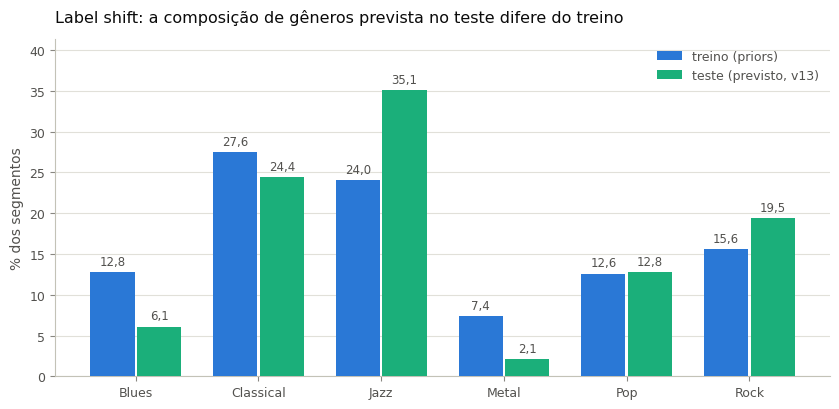

In [15]:
inv_cod = {v: k for k, v in COD.items()}
prior_treino = (df_tr["GENRE"].value_counts(normalize=True).reindex(list(COD)) * 100)
dist_v9 = (pd.Series(subs["v13"]).map(inv_cod).value_counts(normalize=True)
           .reindex(list(COD)) * 100)

x = np.arange(len(COD))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
b1 = ax.bar(x - 0.19, prior_treino.values, width=0.36, color=AZUL, label="treino (priors)", zorder=3)
b2 = ax.bar(x + 0.19, dist_v9.values, width=0.36, color=AQUA, label="teste (previsto, v13)", zorder=3)
for barras in (b1, b2):
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                fmt_br(b.get_height()), ha="center", va="bottom", fontsize=8.5, color=TINTA_2)
estilizar(ax, "Label shift: a composição de gêneros prevista no teste difere do treino")
ax.set_xticks(x)
ax.set_xticklabels(list(COD), fontsize=9)
ax.set_ylabel("% dos segmentos", color=TINTA_2)
ax.set_ylim(0, max(prior_treino.max(), dist_v9.max()) * 1.18)
ax.legend(frameon=False, fontsize=9, labelcolor=TINTA_2)
plt.tight_layout()
plt.show()

## 10. O que foi testado e **não** funcionou

Tão importante para o artigo quanto a receita vencedora é o registro das ideias que falharam — e o motivo:

| Ideia | Motivação | Por que falhou |
|---|---|---|
| **Validação local como métrica de decisão** | prática padrão | segmentos da mesma gravação caem dos dois lados da divisão → o modelo reconhece a *gravação*, não o gênero; 97,6% local virou 72,8% real |
| **Ponderação por importância como métrica-proxy** (pesos adversariais `w = p/(1−p)` na validação) | simular o domínio do teste | continuou otimista (~0,96): o vazamento intra-gravação domina qualquer reponderação |
| **Propagação kNN de rótulos no teste** (suavizar previsões pelos vizinhos no espaço de features) | segmentos vizinhos deveriam compartilhar rótulo | **piorou de −0,8 a −4,9 p.p.** no conjunto de avaliação interno; a coerência de vizinhança do teste era só 79% — vizinhança em feature ≠ mesma música |
| **Reconstruir "músicas" por clustering** dos segmentos do teste (recuperar o ID de música perdido e prever por voto) | previsão por música é mais estável | os componentes conexos colapsam num blob gigante (10 mil+ segmentos); e sem rótulos não há validação honesta possível para calibrar o corte |
| **Correção de label shift só ao final** (v4) | mais simples | funciona (+0,77 p.p.), mas deixa o viés de composição agir durante as rodadas — o EM na rodada + cotas (v5) rendeu mais |
| **Limiar global de confiança na pseudo-rotulagem** (v3/v4) | prática padrão de self-training | viés de composição: Classical inunda os pseudo-rótulos, o prior do Metal colapsa 1,9% → 0,8% e o erro se auto-reforça — resolvido pelas cotas por classe (v5) |
| **Suavização por clusters de gravação (v7)** — média das probs v6 entre colegas de clusters finos K-Means no espaço bruto (multi-resolução, inspirada nos vencedores do ISMIS 2011, que fizeram 87,5% com re-rotulagem por clusters) | segmentos da mesma gravação compartilham o gênero; clusters finos tinham pureza 0,990 no treino | **+1,02 p.p. na validação-espelho** (split por pseudo-música, 3 folds positivos), mas **0,79514 no LB (−0,58 p.p. vs v6)** — o espelho local, por melhor desenhado que seja, não reproduz o regime do covariate shift real; mudanças concentradas em segmentos de baixa confiança viraram moeda ao ar viciada |
| **Features de geometria espectral no pipeline (v8)** — as 16 `GEO_*` da seção 6.1 somadas às 255 do processo v6 | matematicamente sólidas, mais invariantes ao shift (AUC adv. isolada 0,858), SVM +0,08 p.p. local | **0,79132 no LB (−0,96 p.p. vs v6)** — redundantes com a forma espectral que FE_*/DCT_* já capturam; perturbaram a representação de um pipeline em ótimo delicado. A MESMA informação de música que falhou aqui e na v7 rendeu **+1,6 p.p. na v9**, quando entrou pela seleção de pseudo-rótulos |
| **Consenso multi-nível com fallback (v10)** — estender o voto de consenso a clusters K-Means mais grossos (k=5063/3544, limiares 0,65/0,70), cobrindo 88,6% do teste | mais cobertura para o mecanismo vencedor da v9 | **0,81365 no LB (−0,32 p.p. vs v9)** — a pureza dos clusters grossos (~0,95-0,97 no treino) não sobrevive ao shift; só o nível fino (pureza 0,99) transfere. A cobertura viável veio depois por outra via: grafos kNN-mútuo (v13) |
| **Média de passadas do laço (v12)** — média das probabilidades v9+v11 | médias de processos sempre tinham somado (v6) | **0,81620 no LB (abaixo dos 0,81748 da v11)** — a 2ª passada é um refinamento da 1ª, não um processo independente; misturar devolve os erros que a iteração tinha corrigido |
| **Frações de incorporação acima de 0,90** (testado na validação da v14) | os vencedores incorporavam o teste inteiro | a acurácia dos rótulos incrementais colapsa de ~82% (até 90%) para 61-79% (92%+) — vetado pela validação de pool antes de custar uma submissão |

## 11. Conclusões e lições

1. **Desconfie de validações locais espetaculares.** 97,6% com CV estável parecia inatacável; era um artefato de vazamento estrutural (segmentos da mesma gravação). Quando os dados têm agrupamentos ocultos (música, paciente, sessão, dispositivo), a divisão de validação precisa respeitá-los — e, se o identificador do grupo não existe, **nenhuma métrica local é confiável em valor absoluto**.
2. **Validação adversarial é o diagnóstico mais barato que existe** para covariate shift: um classificador treino×teste e uma AUC. Além do veredito (≈0,97), as importâncias apontam *quais* features carregam o shift — aqui, timbre e condição de gravação (`MFCC2`, `ASE20–32`, `SFM22–24`) — e sugerem a resposta (representações de *forma* espectral, como a DCT).
3. **Sob shift, otimize princípios, não a métrica local:** representações mais invariantes ao fator de shift (DCT sobre bandas, princípio dos MFCCs) + adaptação ao domínio do teste (pseudo-rotulagem) renderam +5,7 p.p. sobre o SVM puro.
4. **Self-training precisa de controle de distribuição.** A seleção ingênua por confiança tem viés de composição que se auto-reforça e colapsa as classes minoritárias. As duas peças da v5 — EM de Saerens **dentro** de cada rodada (com os priors do treino atual, ponderados) e **cotas por classe** proporcionais aos priors estimados (alinhamento de distribuição, estilo FixMatch) — foram individualmente necessárias.
5. **Média sobre rodadas e sobre execuções paga o último degrau.** A previsão pela média das 3 últimas rodadas (dentro de cada membro) e o bagging de 4 execuções independentes do processo completo (v6) converteram variância de processo em +0,45 p.p. — a diferença entre 0,79642 e **0,80089**.
6. **Registre as falhas.** kNN, reconstrução de músicas e a métrica ponderada falharam por razões instrutivas — cada falha refinou o entendimento do problema e está documentada na seção 10.
7. **Nem a melhor validação-espelho substitui o teste real.** A v7 (suavização por clusters de gravação) ganhou +1,02 p.p. numa validação desenhada com cuidado — split por pseudo-música, três folds positivos, guardrails — e ainda assim **perdeu 0,58 p.p. no leaderboard**. E a v8 (features geométricas bem construídas e localmente neutras-positivas) perdeu 0,96 p.p. Sob covariate shift severo, melhorias validadas localmente são indistinguíveis de ruído.
8. **A mesma informação pode falhar ou vencer dependendo da PORTA por onde entra.** A estrutura segmento→música falhou como pós-processamento (v7) e a invariância de forma falhou como feature extra (v8) — mas a estrutura de música rendeu **+1,6 p.p. (v9)** quando entrou pela **seleção de pseudo-rótulos**, o único componente do pipeline cujo aprimoramento transferiu para o leaderboard em todas as tentativas (v3→v6, v9, v11, v13). Em adaptação de domínio, *o que* o modelo estuda importa mais do que *como* ele responde.
9. **Valide a peça na métrica da porta certa antes de treinar.** A v13 (+0,64 p.p., recorde 0,82386) empilhou três melhorias — grupos kNN-mútuo mais puros, peso maior para o consenso, 8 membros — todas aprovadas ANTES do treino por experimentos que medem exatamente o que a porta de seleção entrega: a **acurácia real dos pseudo-rótulos aceitos**. As reprovadas nesses mesmos experimentos (fusão hierárquica, kNN k≥5, frações >0,90) nunca custaram uma submissão.

**Placar final: 0,83024 — 1º lugar no leaderboard.** Do choque inicial (0,72814 com 97,6% de validação local) ao resultado final, foram **+10,2 p.p.** construídos exclusivamente com diagnóstico de shift, adaptação de domínio pela seleção de pseudo-rótulos e validações dirigidas à porta certa do pipeline.

---

### Apêndice — arquivos e ambiente

| Arquivo | Conteúdo |
|---|---|
| `Classificacao_Generos_KMeans.ipynb` | etapa não supervisionada (v1/v2) |
| `Classificacao_Generos_Modelo_Avancado.ipynb` | comparação dos 7 modelos supervisionados |
| `Classificacao_Generos_Espectral_Pseudo.ipynb` | v3: DCT + pseudo-rotulagem |
| `solucao_final/pipeline_comum.py` | features (FE_*/DCT_*/GEO_*) + tratamento (compartilhado v5→v8) |
| `solucao_final/gerar_v5.py` · `solucao_final/gerar_v6.py` | scripts originais que geraram as submissões v5 e v6 |
| `solucao_final/v7_fase_*.py` | experimento v7 (clustering multi-resolução + suavização) — falhou no LB |
| `solucao_final/gerar_v9.py` → `gerar_v14.py` | a série do laço de consenso (v9 em diante; execução paralela por membro) |
| `solucao_final/experimento_clusters_v13.py` · `experimento_pool_v13.py` · `experimento_fracoes_v14.py` | as validações de pool que aprovam/vetam cada peça antes do treino |
| `submissao_v6.csv` | v6 — LB 0,80089 |
| `submissao_v7.csv` · `submissao_v8.csv` · `submissao_v10.csv` · `submissao_v12.csv` | regressões documentadas (0,79514 / 0,79132 / 0,81365 / 0,81620) |
| `submissao_v13.csv` | v13 — LB 0,82386 |
| `submissao_v14.csv` | **melhor submissão (final) — LB 0,83024** |

**Ambiente:** Python 3.12.8 · scikit-learn 1.8 · pandas 2.1.4 · LightGBM · SciPy (DCT). Para reproduzir a submissão final do zero: `PARAMS["EXECUTAR_PIPELINE_FINAL"] = True` neste notebook, ou os scripts de `solucao_final/` (executados em etapas, com estado intermediário em disco).